In [226]:
import numpy as np
import diplib as dip
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats

DATA_DIR   = Path.cwd()                       # maybe change to ur data directory
FNAME      = "w8t1t2_d7_{}.tif"               # filename template
EMBRYO_IDS = [f"{i:02d}" for i in range(1, 59)]   # 58 unique 

## 1. Segmentation technique 


**Pre-processing & algorithm**
1. **Estimate the background colour** as the median RGB of the four image
   corners background dominates the corners (for most images) the median ignores any stray
   material that touches a corner.
2. **Colour-distance map** $d(x) = ‖ rgb(x) − bg ‖₂$. Every embryo part
lies far from the background colour so they should retain high values
3. **Gaussian smoothing** (σ = 3) to suppress pixel noise/speckle.
4. **Threshold** 
5. **Morphological clean-up:** closing -> fill holes ->
   area-opening (removes small background debris) -> keep the largest connected
   component.



In [227]:
def load_rgb(embryo_id):
    """Load one embryo's image as a RGB array."""
    img=dip.ImageRead(str(DATA_DIR / FNAME.format(embryo_id)))
    #img.Show()
    array=np.asarray(img)
    return array

load_rgb(EMBRYO_IDS[0])  # test loading one image

def estimate_background(rgb, s=50): #CHANGED s 
    """Background colour = median RGB over the four corner patches."""
    corners = np.concatenate([
        rgb[:s, :s].reshape(-1, 3),  rgb[:s, -s:].reshape(-1, 3),
        rgb[-s:, :s].reshape(-1, 3), rgb[-s:, -s:].reshape(-1, 3)])
    return np.median(corners, axis=0)


def keep_largest(mask):
    labs  = dip.Label(mask)
    meas = dip.MeasurementTool.Measure(labs, None, ["Size"])
    ids  = list(meas.Objects())
    if not ids:
        return mask
    biggest = ids[int(np.argmax([meas[i]["Size"][0] for i in ids]))]
    return dip.Image(np.asarray(labs) == biggest)


def segment_embryo(rgb, sigma=3.0, r=9, min_size=3000):
    """Return a boolean mask of the embryo (colour-distance + triangle threshold)."""
    bg     = estimate_background(rgb)
    dist   = np.sqrt(((rgb - bg)**2).sum(axis=2))            # 1. distance pythagorean since we have 3D RGB data
    smooth = dip.Gauss(dip.Image(dist), sigma)               # 2. noise suppression
    _ , t   = dip.Threshold(smooth) 
    mask   = dip.Image(np.asarray(smooth) > (0.7 * t))       # 3. threshold and extract mask - CHANGED - added a multiplier to the threshold 
    mask   = dip.Closing(mask, dip.SE(r, "elliptic"))        # 4. close gaps
    mask   = dip.FillHoles(mask)                             # 5. fill interior holes
    mask   = dip.AreaOpening(mask, filterSize=min_size)      # 6. drop small debris
    mask   = keep_largest(mask)                              # 7. largest object only
    return np.asarray(mask)


def crop_to_mask(img, mask, pad=40):
    """Crop the image to the bounding box of the mask"""
    ys, xs = np.where(mask)
    if len(ys) == 0:
        return img
    y0, y1 = max(ys.min() - pad, 0), min(ys.max() + pad, mask.shape[0])
    x0, x1 = max(xs.min() - pad, 0), min(xs.max() + pad, mask.shape[1])
    return img[y0:y1, x0:x1]


def to_uint8(rgb):
    """16-bit float RGB -> 8-bit for display."""
    return (rgb / 256.0).clip(0, 255).astype(np.uint8)

In [228]:
#lists to store results of segmentation and area measurement + original images for display
panel_orig, panel_mask, areas = [], [], []

for eid in EMBRYO_IDS:
    rgb  = load_rgb(eid)
    mask = segment_embryo(rgb)
    panel_orig.append(to_uint8(crop_to_mask(rgb,  mask)))
    panel_mask.append(crop_to_mask(mask, mask))
    areas.append(int(mask.sum()))
    print(f"embryo {eid}:  area = {areas[-1]:>7d} px")

print(f"\nSegmented {len(panel_mask)} embryos.")

embryo 01:  area =  232847 px
embryo 02:  area =  275866 px
embryo 03:  area =  212634 px
embryo 04:  area =  401102 px
embryo 05:  area =  227200 px
embryo 06:  area =  219629 px
embryo 07:  area =  260982 px
embryo 08:  area =  169489 px
embryo 09:  area =  245426 px
embryo 10:  area =  268251 px
embryo 11:  area =  215716 px
embryo 12:  area =  195818 px
embryo 13:  area =  233633 px
embryo 14:  area =  298674 px
embryo 15:  area =  298062 px
embryo 16:  area =  149956 px
embryo 17:  area =  305481 px
embryo 18:  area =  149247 px
embryo 19:  area =  247555 px
embryo 20:  area =  210012 px
embryo 21:  area =  259330 px
embryo 22:  area =  325193 px
embryo 23:  area =  226559 px
embryo 24:  area =  192531 px
embryo 25:  area =  150556 px
embryo 26:  area =  207965 px
embryo 27:  area =  286644 px
embryo 28:  area =  195022 px
embryo 29:  area =  114098 px
embryo 30:  area =  152737 px
embryo 31:  area =  227586 px
embryo 32:  area =  232239 px
embryo 33:  area =  154812 px
embryo 34:

## 2. Panel of the original images (Part 1.2)

All 58 embryos are cropped to their bounding box and rescaled 

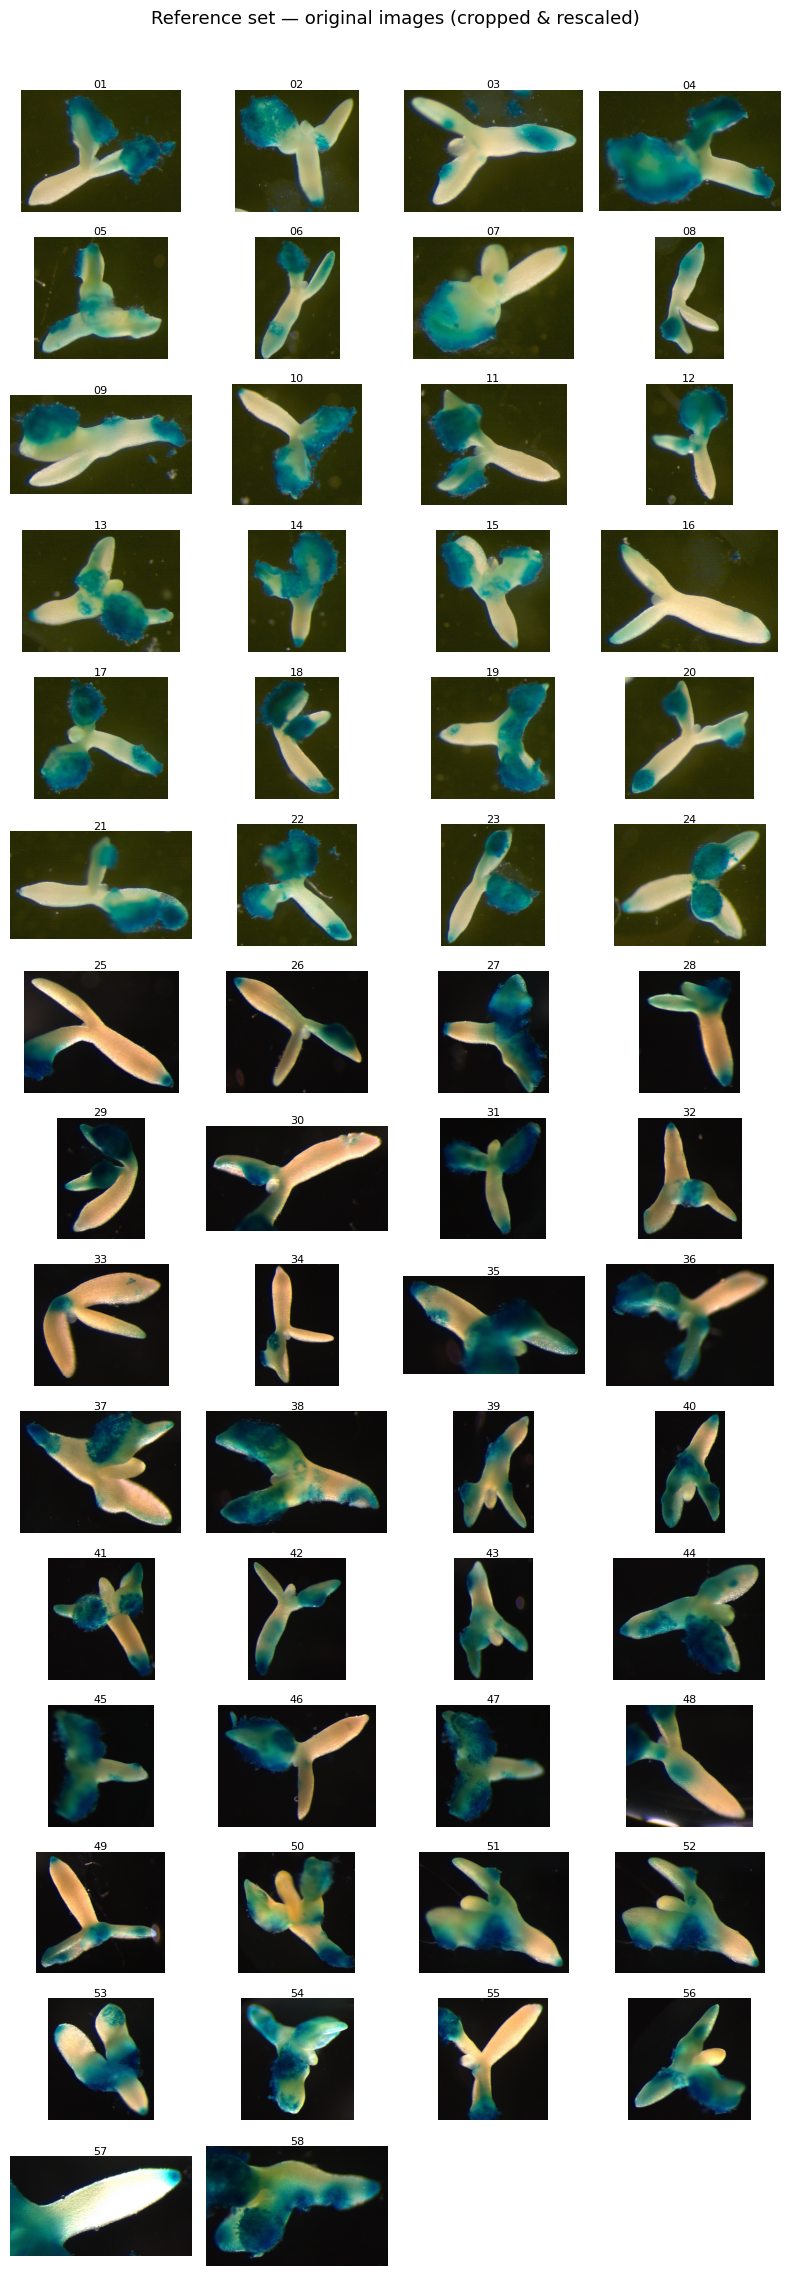

In [229]:
def show_panel(images, labels, nrows=15, ncols=4, binary=False, suptitle=None):
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 2.0, nrows * 1.5))
    for k, ax in enumerate(axes.ravel()):
        ax.axis("off")
        if k < len(images):
            ax.imshow(images[k], cmap="gray" if binary else None)
            ax.set_title(labels[k], fontsize=8, pad=1)
    if suptitle:
        fig.suptitle(suptitle, fontsize=13, y=1.01)
    plt.tight_layout()
    return fig

fig = show_panel(panel_orig, EMBRYO_IDS,
                 suptitle="Reference set — original images (cropped & rescaled)")
plt.show()

## 3. Panel of the binary masks  - method works for black background but not for green 



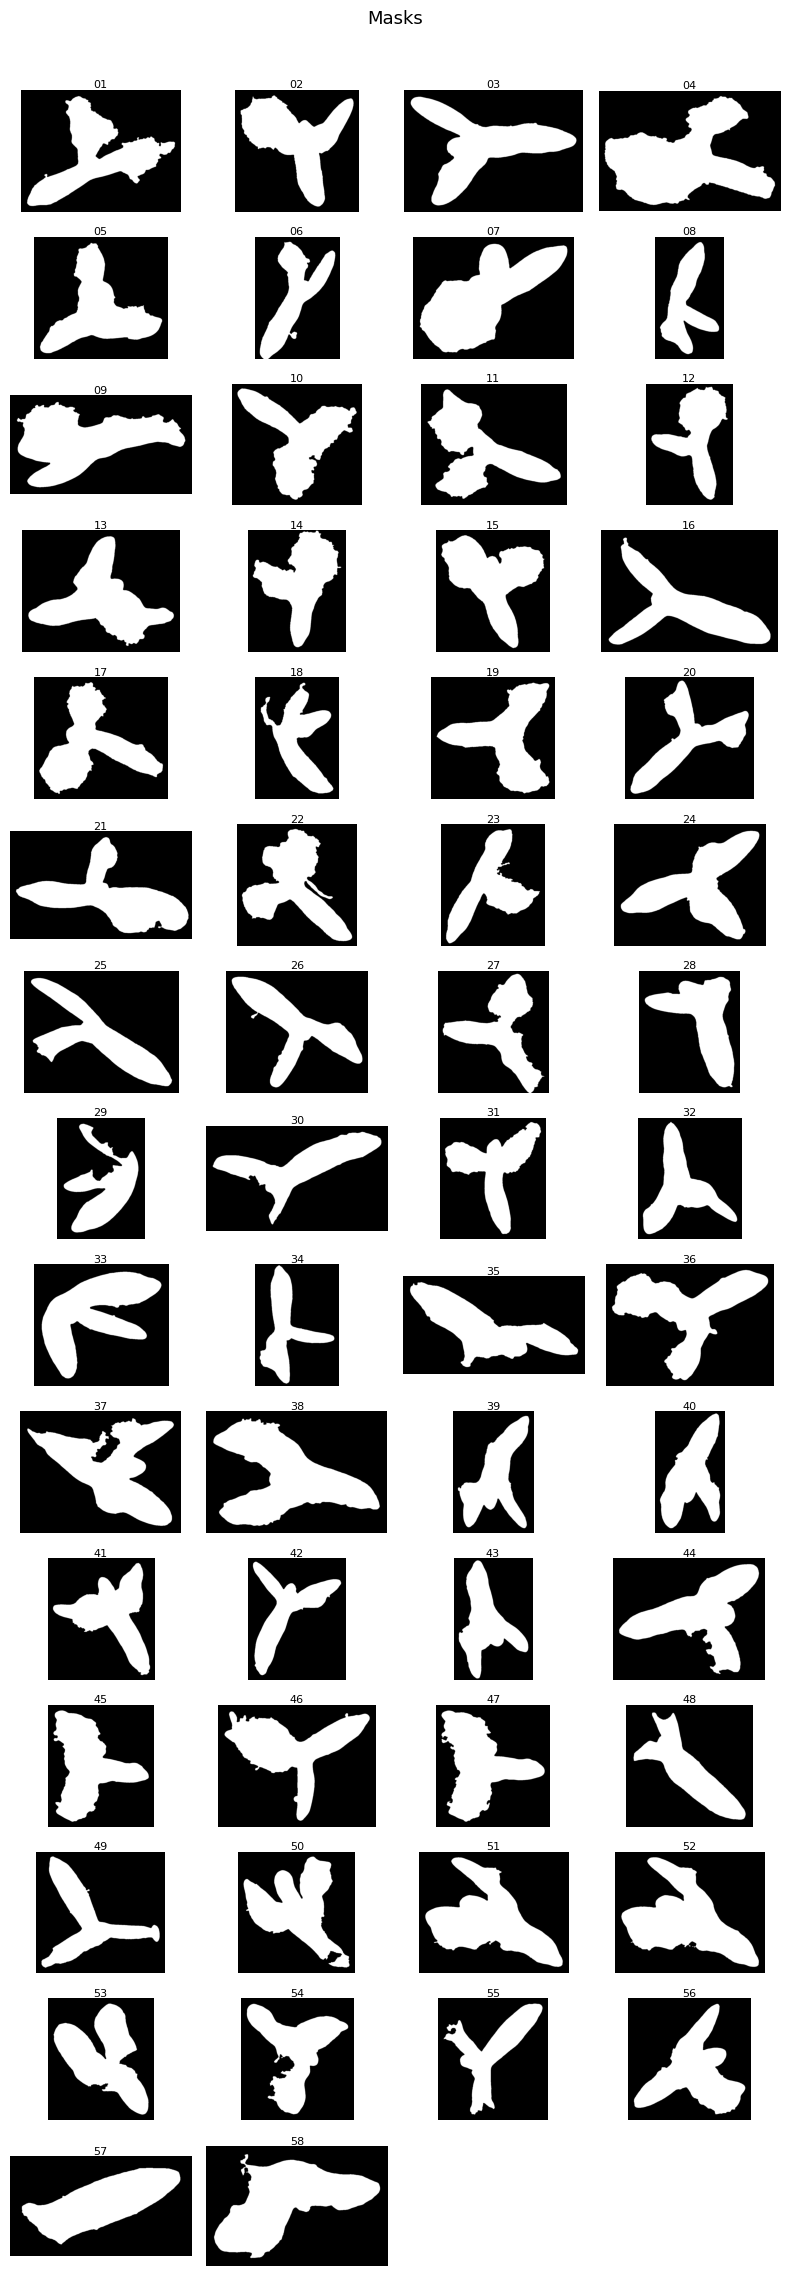

In [230]:
fig = show_panel(panel_mask, EMBRYO_IDS, binary=True,
                 suptitle="Masks")
plt.show()

---
# Part 2 — Shape, size and gene-expression measurements



## 2.1 — Size and shape features


In [231]:
import pandas as pd
from sklearn.preprocessing import StandardScaler,RobustScaler
from sklearn.cluster import KMeans


def blue_mask(rgb, mask, frac=0.40, erode=6, min_speck=150):
    """Boolean mask of blue (gene-expression) pixels inside the embryo.
    f_B = B/(R+G+B) > frac then pixel is blue."""
    rgb = rgb.astype(np.float64)  # 16-bit to  float. If we don't do this, the division will be wrong and frac_blue will be zero everywhere.
    interior = np.asarray(dip.BinaryErosion(dip.Image(mask), 1, erode)).astype(bool)
    R, G, B  = rgb[..., 0], rgb[..., 1], rgb[..., 2]
    frac_blue = B / (R + G + B + 1e-6)  #  avoid division by zero
    bm = (frac_blue > frac) & interior
    bm = np.asarray(dip.AreaOpening(dip.Image(bm), filterSize=min_speck)).astype(bool)
    return bm


def measure_shape(mask):
    """Size + shape of a single-object boolean mask"""
    lab = dip.Label(dip.Image(mask))
    m = dip.MeasurementTool.Measure(
              lab, None, ["Size", "Perimeter", "Roundness", "Solidity"])
    
    g = lambda k: float(m[1][k][0])
    return dict(area=g("Size"), perimeter=g("Perimeter"), roundness=g("Roundness"),
                solidity=g("Solidity"))

In [232]:
masks, blue_masks, records = {}, {}, []
for eid in EMBRYO_IDS:
    rgb  = load_rgb(eid)
    mask = segment_embryo(rgb)
    bm   = blue_mask(rgb, mask)
    masks[eid], blue_masks[eid] = mask, bm
    sh = measure_shape(mask)
    blue_abs = int(bm.sum())
    records.append({"id": eid, **sh, "blue_abs": blue_abs,
                    "blue_rel": blue_abs / sh["area"]})

features = pd.DataFrame(records).set_index("id")
show = features.copy()
show["area"]      = show["area"].astype(int)
show["perimeter"] = show["perimeter"].round(0).astype(int)
show[["roundness", "solidity", "blue_rel"]] = \
        show[["roundness", "solidity", "blue_rel"]].round(3)
show

,area,perimeter,roundness,solidity,blue_abs,blue_rel
id,,,,,,
01,232847,3672,0.217,0.588,90101,0.387
02,275866,3103,0.360,0.659,97523,0.354
03,212634,2984,0.300,0.602,26099,0.123
04,401102,3865,0.337,0.702,259945,0.648
05,227200,2779,0.370,0.659,28087,0.124
06,219629,3253,0.261,0.647,51865,0.236
07,260982,2610,0.482,0.806,74679,0.286
08,169489,2622,0.310,0.649,30476,0.180
09,245426,3033,0.335,0.727,73608,0.300


Viusualisation

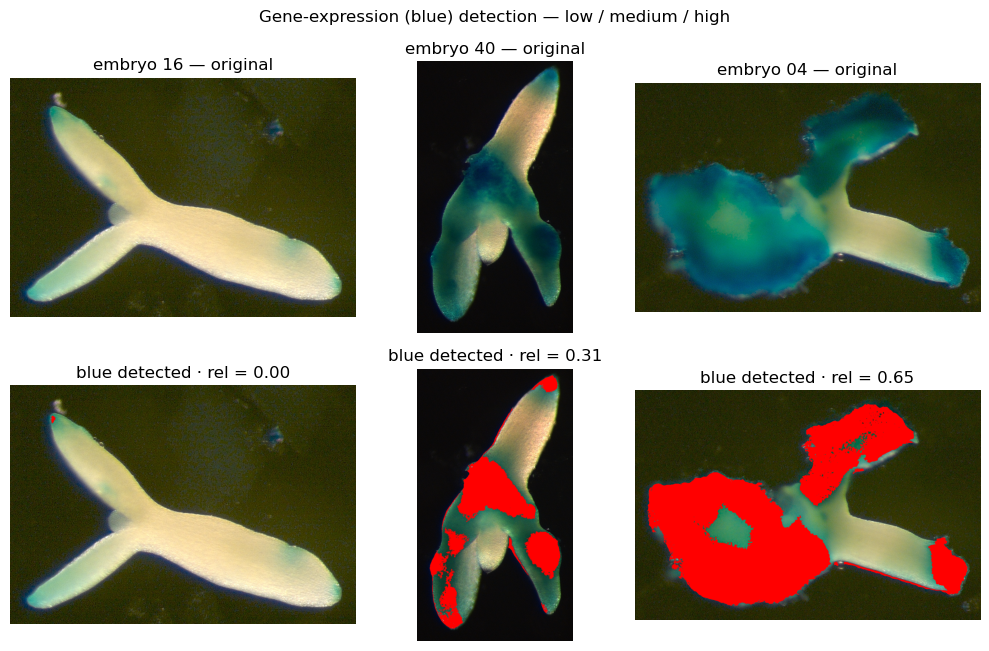

In [233]:
def overlay_blue(eid, colour=(255, 0, 0)):
    rgb  = load_rgb(eid)
    disp = to_uint8(rgb).copy()
    disp[blue_masks[eid]] = colour                       
    return crop_to_mask(disp, masks[eid]), crop_to_mask(to_uint8(rgb), masks[eid])

clean    = features[features.area > 120000].sort_values("blue_rel")   # representative
examples = [clean.index[0], clean.index[len(clean)//2], clean.index[-1]]

fig, ax = plt.subplots(2, 3, figsize=(10, 6.6))
for j, eid in enumerate(examples):
    over, orig = overlay_blue(eid)
    ax[0, j].imshow(orig); ax[0, j].axis("off"); ax[0, j].set_title(f"embryo {eid} — original")
    ax[1, j].imshow(over); ax[1, j].axis("off")
    ax[1, j].set_title(f"blue detected · rel = {features.loc[eid, 'blue_rel']:.2f}")
fig.suptitle("Gene-expression (blue) detection — low / medium / high", fontsize=12)
plt.tight_layout(); plt.show()

## Part 2.2 Use K-mmean neighbours on the data of the tabel to make 3 distinct classes - NOTE can use all features but I think in the assignment it is meant to use ionly shape and size

In [234]:
features_copy = features.copy()

print(features_copy.columns.tolist())
X =  RobustScaler().fit_transform(features_copy[["area", "roundness", "solidity"]]) 
kmeans = KMeans(3, random_state=0)
kmeans.fit(X)
clusters = kmeans.predict(X)
centroids = kmeans.cluster_centers_
print("clusters:", clusters)
print("centroids:", centroids)
features_copy["cluster"] = clusters
features_copy.sort_values("cluster")


def feature_ranges_per_cluster(features, feature_name):
    return features.groupby("cluster")[feature_name].agg(["min", "max"])


for feature in ["area", "roundness", "solidity", "blue_rel"]:
    print(f"\n{feature} ranges per cluster:")
    print(feature_ranges_per_cluster(features_copy, feature))

['area', 'perimeter', 'roundness', 'solidity', 'blue_abs', 'blue_rel']
clusters: [1 0 1 0 0 1 2 1 0 0 1 0 0 0 0 1 0 1 0 1 0 0 0 0 1 1 0 2 1 1 0 0 1 1 2 0 1
 0 0 0 0 1 0 0 0 1 0 2 1 0 0 0 0 1 1 0 2 2]
centroids: [[ 0.48239677  0.27054749  0.17795967]
 [-0.65928897 -0.63230742 -0.66428548]
 [-0.97981836  1.45922674  1.13688072]]

area ranges per cluster:
              min       max
cluster                    
0        192531.0  401102.0
1        114098.0  232847.0
2         66696.0  260982.0

roundness ranges per cluster:
              min       max
cluster                    
0        0.237885  0.403799
1        0.201240  0.309867
2        0.338309  0.533835

solidity ranges per cluster:
              min       max
cluster                    
0        0.591944  0.788554
1        0.488444  0.677700
2        0.700850  0.926745

blue_rel ranges per cluster:
              min       max
cluster                    
0        0.123622  0.648077
1        0.001014  0.386954
2        0.066421  0.4

c:\Users\ivanb\anaconda3\envs\rl_course\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [ ]:
def assign_cluster(row):
    """ 0 = large ; 1 = small(elongated) ; 2 = compact / round """
    a, r, s = row["area"], row["roundness"], row["solidity"]

    # cluster 2 — compact/round: very high roundness, OR (high roundness & solidity & not large)
    if r >= 0.45 or (s >= 0.70 and r >= 0.33 and a < 215_000):
        return 2
    # cluster 0 vs 1 — large vs small
    if a >= 215_000:
        return 0
    return 1

features_copy["cluster_rule"] = features_copy.apply(assign_cluster, axis=1)
print("agreement:", (features_copy["cluster_rule"] == features_copy["cluster"]).mean())

agreement: 0.9137931034482759
